# GraphSAGE Accessibility Modeling

Predict tract-level job accessibility using:
- ACS socio-economic predictors
- Spatial tract adjacency graph

Target:
- jobs reachable within 30 minutes

In [1]:
# NAME = "atlanta"

# STATE = "08"

# COUNTIES = [
#     "031"
# ]

CITY = "atlanta"
STATE = "13"
COUNTIES = ["121", "089", "067", "135"]

TARGET_VARIABLE = "jobs_30min"

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

from sklearn.cluster import KMeans

In [3]:
# %%
predictors = pd.read_parquet(
    "../data/processed_predictors/atlanta_2023_predictor_dataset.parquet"
)

predictors["tract_id"] = (
    predictors["tract_id"]
    .astype(str)
)

print("Predictor shape:", predictors.shape)

predictors.head(2)

Predictor shape: (936, 44)


,tract_id,total_population,population_density,pct_under_18,pct_18_64,pct_over_65,sex_ratio,median_age,avg_household_size,households,...,median_home_value,housing_density,median_year_built,land_area_km2,distance_to_cbd_km,pct_white_non_hispanic,pct_black,pct_hispanic_latino,pct_asian,pct_other_multiracial
0,13089023315,7518,219.008881,0.242219,0.618250,0.139532,0.908606,39.900002,3.16,2362,...,294200.0,70.555931,2003.0,34.327377,29.209461,0.048949,0.865656,0.034717,0.020085,0.030593
1,13089021411,4306,1776.086548,0.203669,0.760334,0.035996,1.209338,31.200001,2.11,2045,...,1028700.0,922.278137,1999.0,2.424431,13.285933,0.700186,0.169066,0.058755,0.021598,0.050395


In [4]:
targets = pd.read_parquet(
    "../data/processed_job_accessibility/accessibility_state-GA_counties-121-089-067-135_year-2023_thresholds-15-30-45-60.parquet"
)

targets["from_id"] = (
    targets["from_id"]
    .astype(str)
)

print("Target shape:", targets.shape)

targets.head(2)

Target shape: (936, 5)


,from_id,jobs_15min,jobs_30min,jobs_45min,jobs_60min
0,13089023315,0.0,237,410,4133
1,13089021411,3284.0,65304,312772,585144


In [5]:
url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)

tracts = tracts.to_crs(epsg=4326)

tracts = tracts[
    tracts["COUNTYFP"].isin(COUNTIES)
].copy()

tracts["tract_id"] = (
    tracts["GEOID"]
    .astype(str)
)

print("Tracts:", tracts.shape)

Tracts: (936, 15)


In [6]:
# %%
gdf = tracts.merge(
    predictors,
    on="tract_id",
    how="inner"
)

gdf = gdf.merge(
    targets,
    left_on="tract_id",
    right_on="from_id",
    how="inner"
)

gdf = gpd.GeoDataFrame(
    gdf,
    geometry="geometry"
)

print("Merged shape:", gdf.shape)

gdf.head(2)

Merged shape: (936, 63)


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,pct_white_non_hispanic,pct_black,pct_hispanic_latino,pct_asian,pct_other_multiracial,from_id,jobs_15min,jobs_30min,jobs_45min,jobs_60min
0,13,089,023315,13089023315,1400000US13089023315,233.15,Census Tract 233.15,G5020,S,23306088,...,0.048949,0.865656,0.034717,0.020085,0.030593,13089023315,0.0,237,410,4133
1,13,089,021411,13089021411,1400000US13089021411,214.11,Census Tract 214.11,G5020,S,1667279,...,0.700186,0.169066,0.058755,0.021598,0.050395,13089021411,3284.0,65304,312772,585144


In [7]:
def build_adjacency_edges(gdf):

    gdf = gdf.copy()

    gdf = gdf[
        gdf.geometry.notnull()
    ]

    gdf = gdf[
        gdf.is_valid
    ]

    gdf = gdf.reset_index(drop=True)

    sindex = gdf.sindex

    edges = []

    for idx, geom in enumerate(gdf.geometry):

        possible = list(
            sindex.intersection(
                geom.bounds
            )
        )

        candidates = gdf.iloc[possible]

        neighbors = candidates[
            candidates.geometry.touches(geom)
        ]

        for n_idx in neighbors.index:

            if idx != n_idx:

                edges.append(
                    (idx, n_idx)
                )

    return edges, gdf

In [8]:
edges, gdf = build_adjacency_edges(gdf)

edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

torch.Size([2, 5824])


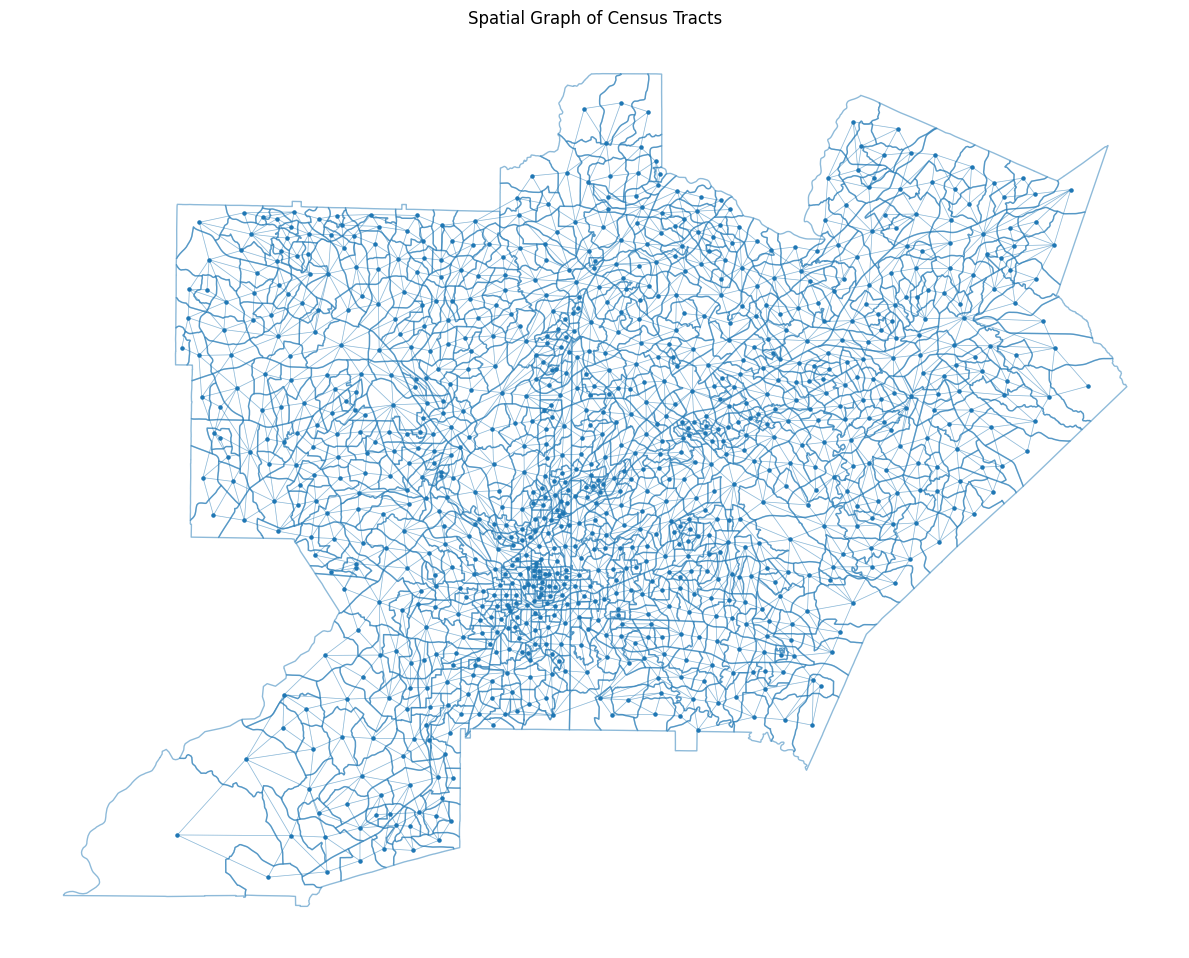

In [9]:
from shapely.geometry import LineString

plot_gdf = gdf.to_crs(epsg=3857).copy()

plot_gdf["centroid"] = (
    plot_gdf.geometry.centroid
)

edge_lines = []

for source, target in edges:

    source_point = plot_gdf.iloc[
        source
    ]["centroid"]

    target_point = plot_gdf.iloc[
        target
    ]["centroid"]

    line = LineString([
        source_point,
        target_point
    ])

    edge_lines.append(line)

edges_gdf = gpd.GeoDataFrame(
    geometry=edge_lines,
    crs=plot_gdf.crs
)

fig, ax = plt.subplots(
    figsize=(12, 12)
)

plot_gdf.boundary.plot(
    ax=ax,
    linewidth=1,
    alpha=0.5
)

edges_gdf.plot(
    ax=ax,
    linewidth=0.5,
    alpha=0.3
)

plot_gdf.set_geometry(
    "centroid"
).plot(
    ax=ax,
    markersize=5
)

ax.set_title(
    "Spatial Graph of Census Tracts"
)

ax.axis("off")

plt.tight_layout()

plt.show()

In [10]:
def prepare_node_features(gdf):

    exclude = [

        # ids
        "tract_id",
        "GEOID",
        "from_id",

        # geometry
        "geometry",

        # targets
        "jobs_15min",
        "jobs_30min",
        "jobs_45min",
        "jobs_60min"
    ]

    # -----------------------------------
    # numeric feature columns
    # -----------------------------------

    feature_cols = gdf.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    feature_cols = [
        c for c in feature_cols
        if c not in exclude
    ]

    # -----------------------------------
    # copy features
    # -----------------------------------

    X_df = gdf[feature_cols].copy()

    # -----------------------------------
    # replace inf values
    # -----------------------------------

    X_df = X_df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # -----------------------------------
    # fill missing
    # -----------------------------------

    X_df = X_df.fillna(0)

    # -----------------------------------
    # convert to numpy
    # -----------------------------------

    X = X_df.values.astype(np.float32)

    # -----------------------------------
    # scale
    # -----------------------------------

    scaler = StandardScaler()

    X = scaler.fit_transform(X)

    # -----------------------------------
    # torch tensor
    # -----------------------------------

    X = torch.tensor(
        X,
        dtype=torch.float
    )

    return X, feature_cols

In [11]:
X, feature_cols = prepare_node_features(gdf)

print("Feature count:", len(feature_cols))

feature_cols

Feature count: 45


['ALAND',
 'AWATER',
 'total_population',
 'population_density',
 'pct_under_18',
 'pct_18_64',
 'pct_over_65',
 'sex_ratio',
 'median_age',
 'avg_household_size',
 'households',
 'median_household_income',
 'per_capita_income',
 'poverty_rate',
 'unemployment_rate',
 'labor_force_participation_rate',
 'snap_participation_rate',
 'public_assistance_rate',
 'pct_high_school',
 'pct_bachelors_degree',
 'pct_graduate_degree',
 'pct_no_vehicle_households',
 'pct_one_vehicle_households',
 'pct_two_plus_vehicle_households',
 'median_commute_time',
 'pct_public_transit_commute',
 'pct_car_commute',
 'pct_walk_commute',
 'pct_bike_commute',
 'pct_work_from_home',
 'housing_units',
 'occupied_housing_units',
 'vacant_housing_units',
 'homeownership_rate',
 'median_rent',
 'median_home_value',
 'housing_density',
 'median_year_built',
 'land_area_km2',
 'distance_to_cbd_km',
 'pct_white_non_hispanic',
 'pct_black',
 'pct_hispanic_latino',
 'pct_asian',
 'pct_other_multiracial']

In [12]:
data = Data(
    x=X,
    edge_index=edge_index
)

print(data)

Data(x=[936, 45], edge_index=[2, 5824])


In [13]:
target_values = np.log1p(
    gdf[TARGET_VARIABLE].values
)

y = torch.tensor(
    target_values,
    dtype=torch.float
)

data.y = y

In [14]:
num_nodes = gdf.shape[0]

# Use projected CRS for accurate geometry operations
split_gdf = gdf.to_crs(epsg=3857).copy()

# tract centroids
split_gdf["centroid"] = (
    split_gdf.geometry.centroid
)

coords = np.column_stack([
    split_gdf.centroid.x,
    split_gdf.centroid.y
])

# Spatial clustering
n_clusters = 5

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=41,
    n_init="auto"
)

cluster_labels = kmeans.fit_predict(coords)

split_gdf["cluster"] = cluster_labels

# Hold out one entire spatial cluster
test_cluster = 3

test_idx = split_gdf.index[
    split_gdf["cluster"] == test_cluster
].to_numpy()

train_idx = split_gdf.index[
    split_gdf["cluster"] != test_cluster
].to_numpy()

# Build masks
train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

train_mask[train_idx] = True

test_mask[test_idx] = True

data.train_mask = train_mask

data.test_mask = test_mask

print("Train nodes:", train_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

Train nodes: 778
Test nodes: 158


/tmp/ipykernel_18740/799429898.py:51: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  train_mask[train_idx] = True


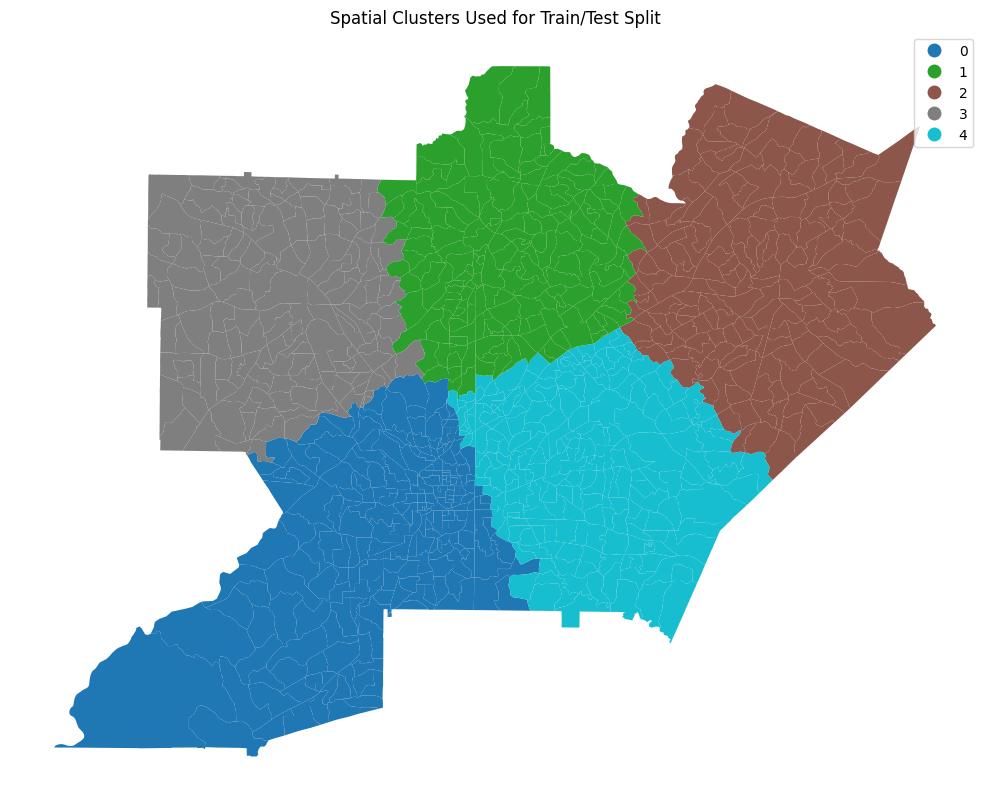

In [15]:
fig, ax = plt.subplots(
    figsize=(10, 10)
)

split_gdf.plot(
    column="cluster",
    categorical=True,
    legend=True,
    ax=ax
)

ax.set_title(
    "Spatial Clusters Used for Train/Test Split"
)

ax.axis("off")

plt.tight_layout()

plt.show()

In [16]:
class GraphSAGE(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels=64
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = SAGEConv(
            hidden_channels,
            hidden_channels
        )

        self.lin = torch.nn.Linear(
            hidden_channels,
            1
        )

    def forward(
        self,
        x,
        edge_index
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.lin(x)

        return x.squeeze()

In [17]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = GraphSAGE(
    in_channels=data.x.shape[1]
).to(device)

data = data.to(device)

print(device)

cuda


In [18]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=1e-4
)

loss_fn = torch.nn.MSELoss()

In [19]:
def train():

    model.train()

    optimizer.zero_grad()

    out = model(
        data.x,
        data.edge_index
    )

    loss = loss_fn(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [20]:
def evaluate():

    model.eval()

    with torch.no_grad():

        out = model(
            data.x,
            data.edge_index
        )

    pred = out[data.test_mask]

    true = data.y[data.test_mask]

    rmse = torch.sqrt(
        loss_fn(pred, true)
    ).item()

    ss_res = (
        (pred - true) ** 2
    ).sum()

    ss_tot = (
        (true - true.mean()) ** 2
    ).sum()

    r2 = (
        1 - ss_res / ss_tot
    ).item()

    return rmse, r2

In [21]:
for epoch in range(1, 201):

    loss = train()

    if epoch % 20 == 0:

        rmse, r2 = evaluate()

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"RMSE {rmse:.4f} | "
            f"R² {r2:.4f}"
        )

Epoch 020 | Loss 5.3033 | RMSE 2.1563 | R² -1.2886
Epoch 040 | Loss 1.6276 | RMSE 1.7790 | R² -0.5577
Epoch 060 | Loss 0.9341 | RMSE 1.7007 | R² -0.4236
Epoch 080 | Loss 0.7539 | RMSE 1.5883 | R² -0.2416
Epoch 100 | Loss 0.6467 | RMSE 1.5424 | R² -0.1709
Epoch 120 | Loss 0.5754 | RMSE 1.5331 | R² -0.1568
Epoch 140 | Loss 0.5209 | RMSE 1.5371 | R² -0.1629
Epoch 160 | Loss 0.4765 | RMSE 1.5538 | R² -0.1883
Epoch 180 | Loss 0.4373 | RMSE 1.5771 | R² -0.2242
Epoch 200 | Loss 0.4015 | RMSE 1.6001 | R² -0.2601


In [22]:
model.eval()

with torch.no_grad():

    pred_log = model(
        data.x,
        data.edge_index
    ).cpu().numpy()

pred = np.expm1(pred_log)

gdf["prediction"] = pred

In [23]:
y_true = np.expm1(
    data.y.cpu().numpy()
)

y_test = y_true[
    data.test_mask.cpu()
]

pred_test = pred[
    data.test_mask.cpu()
]

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_test
    )
)

r2 = r2_score(
    y_test,
    pred_test
)

print("\nFinal Metrics")

print("-------------")

print("RMSE:", round(rmse, 2))

print("R²:", round(r2, 4))


Final Metrics
-------------
RMSE: 394262.92
R²: -373.9782


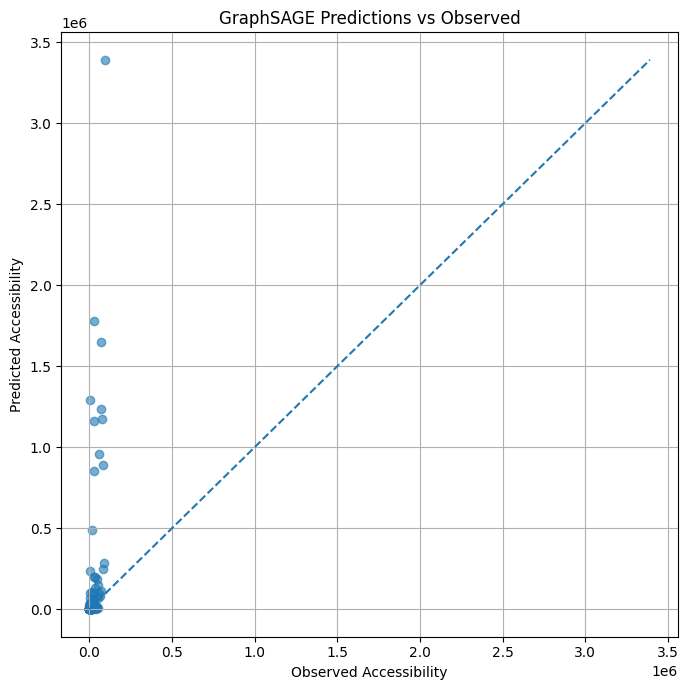

In [24]:
# %%
fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.scatter(
    y_test,
    pred_test,
    alpha=0.6
)

min_val = min(
    y_test.min(),
    pred_test.min()
)

max_val = max(
    y_test.max(),
    pred_test.max()
)

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

ax.set_xlabel(
    "Observed Accessibility"
)

ax.set_ylabel(
    "Predicted Accessibility"
)

ax.set_title(
    "GraphSAGE Predictions vs Observed"
)

ax.grid(True)

plt.tight_layout()

plt.show()

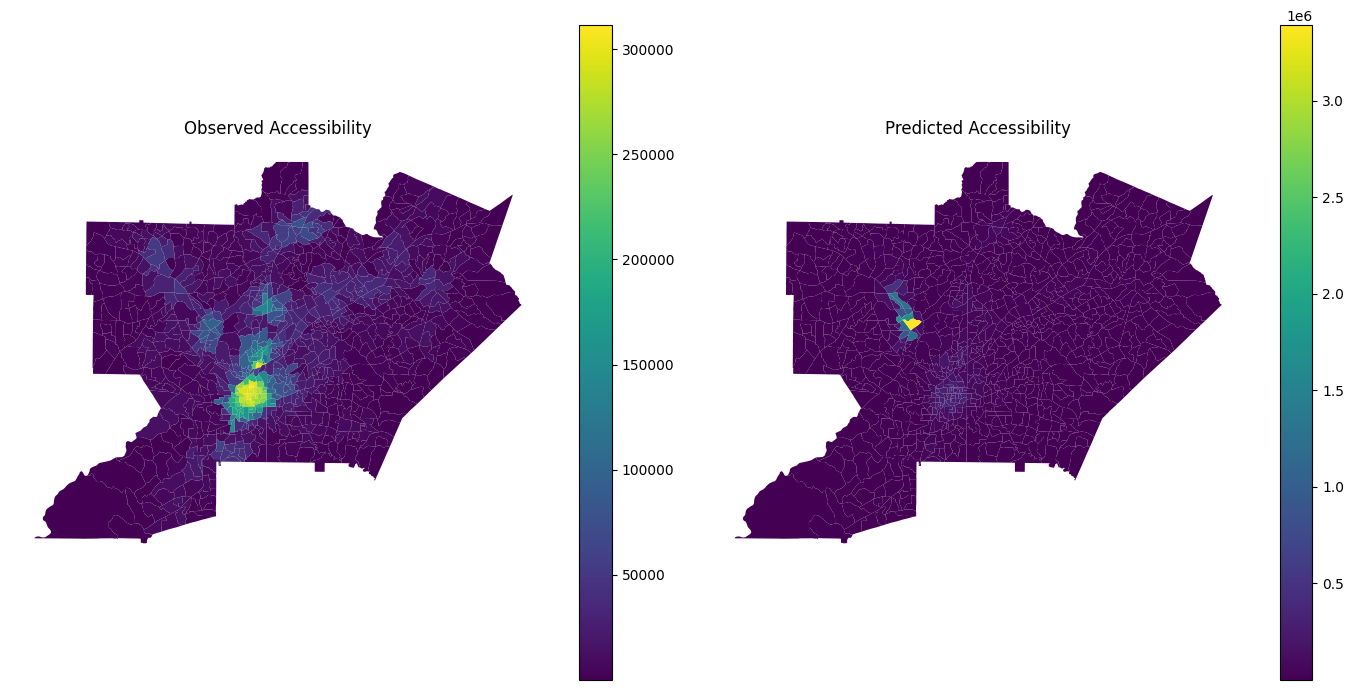

In [25]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7)
)

gdf.plot(
    column=TARGET_VARIABLE,
    cmap="viridis",
    legend=True,
    ax=axes[0]
)

axes[0].set_title(
    "Observed Accessibility"
)

axes[0].axis("off")

gdf.plot(
    column="prediction",
    cmap="viridis",
    legend=True,
    ax=axes[1]
)

axes[1].set_title(
    "Predicted Accessibility"
)

axes[1].axis("off")

plt.tight_layout()

plt.show()

## Spatial Cross-Validation

In [26]:
# SPATIAL CROSS-VALIDATION
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

results = []

all_predictions = []

for test_cluster in range(n_clusters):

    print("\n" + "=" * 60)

    print(f"TEST CLUSTER: {test_cluster}")

    print("=" * 60)

    # SPATIAL SPLIT
    train_idx = split_gdf.index[
        split_gdf["cluster"] != test_cluster
    ].to_numpy()

    test_idx = split_gdf.index[
        split_gdf["cluster"] == test_cluster
    ].to_numpy()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    train_mask[train_idx] = True

    test_mask[test_idx] = True

    # NEW MODEL FOR EACH FOLD
    model = model.__class__(
        in_channels=data.num_node_features
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01,
        weight_decay=5e-4
    )

    criterion = torch.nn.MSELoss()

    # TRAINING
    for epoch in range(200):

        model.train()

        optimizer.zero_grad()

        out = model(
            data.x.to(device),
            data.edge_index.to(device)
        )

        loss = criterion(
            out[train_mask.to(device)],
            data.y[train_mask].to(device)
        )

        loss.backward()

        optimizer.step()

    # EVALUATION
    model.eval()

    with torch.no_grad():

        predictions = model(
            data.x.to(device),
            data.edge_index.to(device)
        )

        y_pred_log = predictions[
            test_mask.to(device)
        ].cpu().numpy()

        y_true_log = data.y[
            test_mask
        ].cpu().numpy()

    # BACK-TRANSFORM
    y_pred = np.expm1(y_pred_log)

    y_true = np.expm1(y_true_log)

    # METRICS
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(f"MAE:  {mae:,.0f}")

    print(f"RMSE: {rmse:,.0f}")

    print(f"R²:   {r2:.4f}")

    results.append({
        "cluster": test_cluster,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

    fold_df = pd.DataFrame({
        "actual": y_true,
        "predicted": y_pred,
        "cluster": test_cluster
    })

    all_predictions.append(fold_df)

# RESULTS DATAFRAME
results_df = pd.DataFrame(results)

print("\n" + "=" * 60)

print("SPATIAL CROSS-VALIDATION SUMMARY")

print("=" * 60)

print(results_df)

print("\nAVERAGE PERFORMANCE")

print(f"Mean MAE:  {results_df['mae'].mean():,.0f}")

print(f"Mean RMSE: {results_df['rmse'].mean():,.0f}")

print(f"Mean R²:   {results_df['r2'].mean():.4f}")

# COMBINED PREDICTIONS
predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)



TEST CLUSTER: 0
MAE:  429,401
RMSE: 3,026,708
R²:   -862.5213

TEST CLUSTER: 1
MAE:  16,981
RMSE: 24,089
R²:   0.2401

TEST CLUSTER: 2
MAE:  15,806
RMSE: 31,242
R²:   -8.6813

TEST CLUSTER: 3
MAE:  146,928
RMSE: 520,248
R²:   -651.9127

TEST CLUSTER: 4
MAE:  24,657
RMSE: 108,712
R²:   -6.0233

SPATIAL CROSS-VALIDATION SUMMARY
   cluster            mae          rmse          r2
0        0  429400.625000  3.026708e+06 -862.521301
1        1   16980.603516  2.408850e+04    0.240072
2        2   15805.558594  3.124164e+04   -8.681314
3        3  146928.296875  5.202480e+05 -651.912720
4        4   24657.183594  1.087116e+05   -6.023257

AVERAGE PERFORMANCE
Mean MAE:  126,754
Mean RMSE: 742,200
Mean R²:   -305.7797
